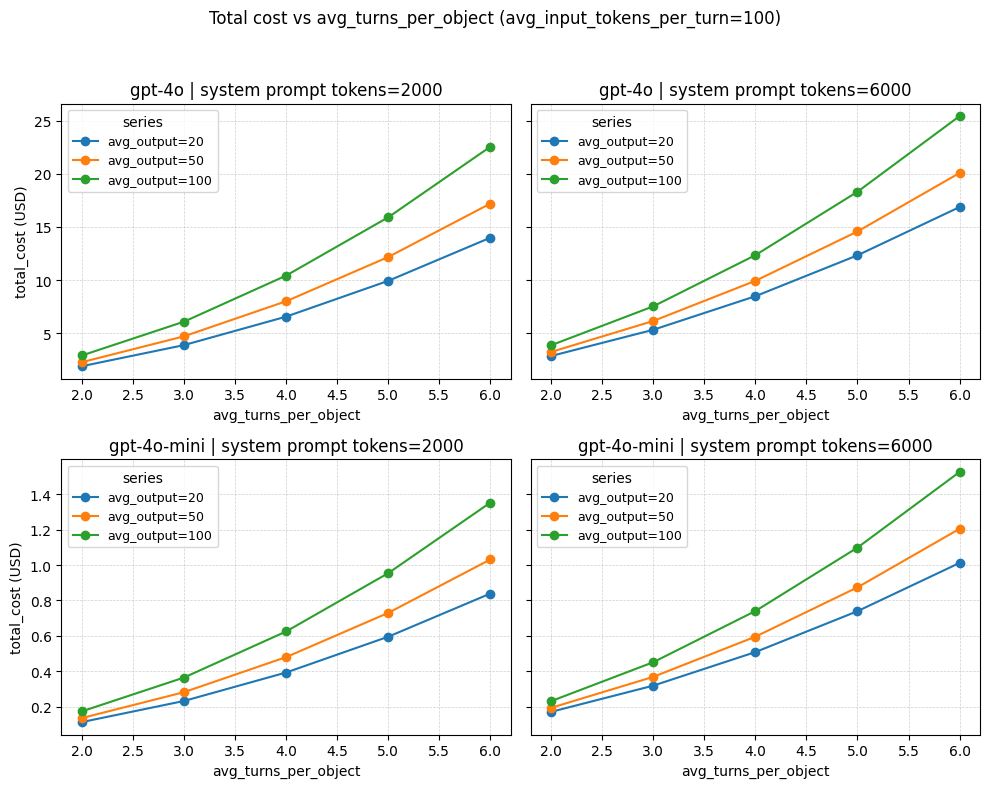

In [66]:
import matplotlib.pyplot as plt

# --- helpers (if you already defined these above, you can delete these two) ---

def get_total_input_and_output_tokens_across_all_turns(
    system_prompt_tokens: int,
    avg_input_tokens_per_turn: int,
    avg_output_tokens_per_turn: int,
    num_turns_for_all_rounds: int,
) -> tuple[int, int]:
    S, I, O, N = system_prompt_tokens, avg_input_tokens_per_turn, avg_output_tokens_per_turn, num_turns_for_all_rounds
    total_input_tokens = N * S + (I + O) * N * (N + 1) // 2
    total_output_tokens = N * O
    return total_input_tokens, total_output_tokens


def compute_cost(
    total_input_tokens: int,
    total_output_tokens: int,
    cost_per_1m_input: float,
    cost_per_1m_output: float,
) -> float:
    return (total_input_tokens / 1_000_000) * cost_per_1m_input + (total_output_tokens / 1_000_000) * cost_per_1m_output


# --- plot costs as a function of system_prompt_tokens, avg_input_tokens_per_turn, avg_output_tokens_per_turn, num_turns_for_all_rounds ---

model_pricing = {
    "gpt-4o": {
        "cost_per_1m_input": 2.50,
        "cost_per_1m_output": 10,
    },
    "gpt-4o-mini": {
        "cost_per_1m_input": 0.15,
        "cost_per_1m_output": 0.6,
    },
}

avg_input_tokens_per_turn = 100
all_system_prompt_tokens = [2000, 6000]

avg_turns_per_object_values = [2, 3, 4, 5, 6, 7, 8, 9, 10][:5]
avg_output_tokens_per_turn_values = [20, 50, 100]

models = list(model_pricing.keys())
m = len(models)
n = len(all_system_prompt_tokens)

fig, axes = plt.subplots(m, n, figsize=(5 * n, 4 * m), sharey="row")
if m == 1 and n == 1:
    axes = [[axes]]
elif m == 1:
    axes = [axes]
elif n == 1:
    axes = [[ax] for ax in axes]

for i, model in enumerate(models):
    pricing_map = model_pricing[model]
    for j, system_prompt_tokens in enumerate(all_system_prompt_tokens):
        ax = axes[i][j]

        for avg_output_tokens_per_turn in avg_output_tokens_per_turn_values:
            costs = []
            for avg_turns_per_object in avg_turns_per_object_values:
                num_turns_for_all_rounds = avg_turns_per_object * 12 * 4

                total_input_tokens, total_output_tokens = (
                    get_total_input_and_output_tokens_across_all_turns(
                        system_prompt_tokens,
                        avg_input_tokens_per_turn,
                        avg_output_tokens_per_turn,
                        num_turns_for_all_rounds,
                    )
                )
                total_cost = compute_cost(
                    total_input_tokens,
                    total_output_tokens,
                    pricing_map["cost_per_1m_input"],
                    pricing_map["cost_per_1m_output"],
                )
                costs.append(total_cost)

            ax.plot(
                avg_turns_per_object_values,
                costs,
                marker="o",
                label=f"avg_output={avg_output_tokens_per_turn}",
            )

        ax.set_title(f"{model} | system prompt tokens={system_prompt_tokens}")
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
        ax.set_xlabel("avg_turns_per_object")

        if j == 0:
            ax.set_ylabel("total_cost (USD)")

        # keep legend manageable: show only on the last column for each row
        ax.legend(title="series", fontsize=9)


fig.suptitle(
    f"Total cost vs avg_turns_per_object (avg_input_tokens_per_turn={avg_input_tokens_per_turn})"
)

fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave 5% at top
# plt.savefig("../outputs/cost_estimate.png", dpi=300, bbox_inches="tight")
plt.show()
